In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Import OK!")

Import OK!


In [3]:
# Chỉ load 100k dòng đầu để EDA — đủ để phân tích
train_trans = pd.read_csv('../data/train_transaction.csv', 
                           nrows=100000)
train_iden  = pd.read_csv('../data/train_identity.csv')

print(f"Transaction: {train_trans.shape}")
print(f"Identity:    {train_iden.shape}")
print(f"RAM dùng: {train_trans.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

Transaction: (100000, 394)
Identity:    (144233, 41)
RAM dùng: 346.4 MB


In [4]:
train_trans.head()


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


isFraud
0    97.439
1     2.561
Name: proportion, dtype: float64


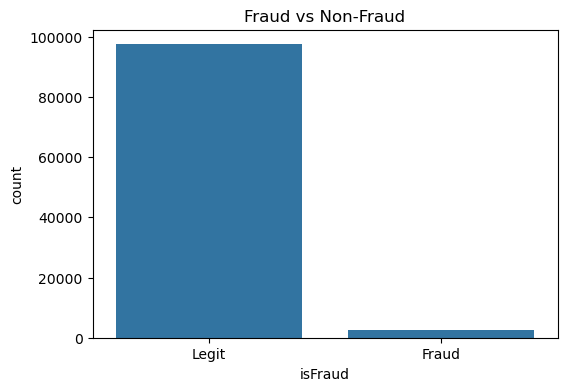

In [5]:
fraud_rate = train_trans['isFraud'].value_counts(normalize=True) * 100
print(fraud_rate)

plt.figure(figsize=(6,4))
sns.countplot(x='isFraud', data=train_trans)
plt.title('Fraud vs Non-Fraud')
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.show()

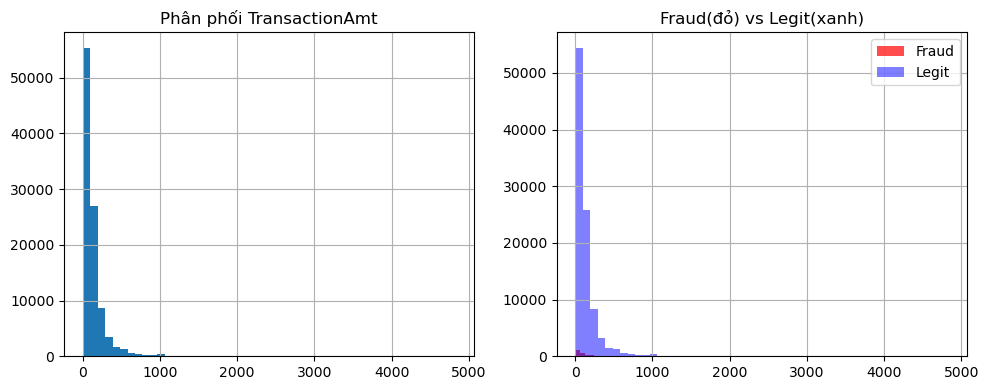

In [6]:
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
train_trans['TransactionAmt'].hist(bins=50)
plt.title('Phân phối TransactionAmt')

plt.subplot(1,2,2)
train_trans[train_trans['isFraud']==1]['TransactionAmt'].hist(bins=50, color='red', alpha=0.7)
train_trans[train_trans['isFraud']==0]['TransactionAmt'].hist(bins=50, color='blue', alpha=0.5)
plt.title('Fraud(đỏ) vs Legit(xanh)')
plt.legend(['Fraud', 'Legit'])
plt.tight_layout()
plt.show()

In [8]:
missing = train_trans.isnull().sum()
missing_pct = (missing / len(train_trans) * 100).sort_values(ascending=False)
print("Top 10 cột nhiều null nhất:")
print(missing_pct.head(10))

Top 10 cột nhiều null nhất:
D7       93.928
dist2    91.769
D13      90.479
D12      89.495
D14      88.847
D6       87.259
M7       83.961
M8       83.961
M9       83.961
D9       78.289
dtype: float64
